# 🔀 Conditional Workflow — Solution

This notebook provides a complete working solution to the Conditional Workflow challenge,
including the optional French Summary agent.

**Pipeline**: Writer → Reviewer → (conditional) → Publisher  
**Optional**: → French Summary agent before Publisher

In [1]:
####### Linux / MacOS Setup Instructions #######
# ! sudo apt update && sudo apt install graphviz -y   # Linux
# ! brew install graphviz                              # macOS

In [2]:
# ! pip install -r ../../../Installation/requirements.txt -U

In [3]:
import os
from typing import cast
from dataclasses import dataclass
from typing_extensions import Literal
from pydantic import BaseModel

In [4]:
from azure.identity.aio import AzureCliCredential
from dotenv import load_dotenv

from agent_framework.azure import AzureAIAgentClient, AzureAIAgentsProvider
from agent_framework import (
    AgentExecutor,
    AgentResponse,
    AgentExecutorRequest,
    AgentExecutorResponse,
    Message,
    WorkflowBuilder,
    WorkflowContext,
    WorkflowEvent,
    executor,
    WorkflowViz
)

In [5]:
load_dotenv()

True

In [6]:
# SOLUTION — Task 1: Agent Instructions

WriterInstructions = """
You are a tech blog content writer for the Casablanca Tech Blog.
When given a topic, write a well-structured article with:
  - A clear title
  - At least 3 paragraphs covering the requested aspects
  - A minimum of 200 words total
  - No code examples — prose only

Return your result as JSON with a single field:
  { "draft_content": "<full article text in Markdown>" }
"""

ReviewerInstructions = """
You are a content reviewer for a tech blog publishing company.
Review the provided draft and check whether it meets these requirements:
  1. The draft content must be at least 200 words.

Return your result as JSON with these fields:
  {
    "review_result": "Yes" or "No",
    "reason": "<brief explanation>",
    "draft_content": "<original draft content, unchanged>"
  }

If the content is 200+ words, set review_result to 'Yes'.
If it is under 200 words, set review_result to 'No' and explain in reason.
"""

PublisherInstructions = """
You are the content publisher for the Casablanca Tech Blog.
When you receive approved draft content, run Python code to save it as a Markdown file.
The filename must be the current date and time in the format YYYYMMDDHHmmss.md
(e.g. 20260320143022.md). Pad single-digit values with a leading zero.
"""

# OPTIONAL — French Summary Instructions
FrenchSummaryInstructions = """
You are a French language editor for the Casablanca Tech Blog.
When given an article in English, produce a 2-3 sentence summary of it in French.
Return only the French summary text — no additional commentary.
Then forward the original English draft content unchanged for publishing.
"""

In [7]:
ARTICLE_TOPIC = """
# Article Topic: The Rise of AI in Casablanca

Write about how artificial intelligence is transforming businesses in Casablanca,
Morocco. Cover at least these three aspects:
1. The growth of the tech startup scene in Casablanca
2. How local enterprises are adopting AI tools
3. Morocco's government digital transformation initiatives

Note: Do NOT include any code examples — prose only.
"""

In [8]:
# SOLUTION — Task 2: Pydantic Output Models

class WriterOutput(BaseModel):
    draft_content: str

class ReviewerOutput(BaseModel):
    review_result: Literal["Yes", "No"]
    reason: str
    draft_content: str

@dataclass
class ReviewResult:
    review_result: str
    reason: str
    draft_content: str

In [9]:
# SOLUTION — Task 3: Reviewer Executor

@executor(id="to_review_result")
async def to_review_result(response: AgentExecutorResponse, ctx: WorkflowContext[ReviewResult]) -> None:
    response_text = response.agent_response.text.strip()
    print(f"Reviewer raw response: {response_text}")

    parsed = ReviewerOutput.model_validate_json(response_text)
    await ctx.send_message(
        ReviewResult(
            review_result=parsed.review_result,
            reason=parsed.reason,
            draft_content=parsed.draft_content,
        )
    )


# SOLUTION — Task 4: Routing Function

def select_targets(review: ReviewResult, target_ids: list[str]) -> list[str]:
    handle_rejection_id, save_draft_id = target_ids
    if review.review_result == "Yes":
        return [save_draft_id]
    else:
        return [handle_rejection_id]


@executor(id="handle_rejection")
async def handle_rejection(review: ReviewResult, ctx: WorkflowContext[str]) -> None:
    await ctx.yield_output(f"Draft rejected: {review.reason}. Please revise and resubmit.")


@executor(id="save_draft")
async def save_draft(review: ReviewResult, ctx: WorkflowContext[AgentExecutorRequest]) -> None:
    await ctx.send_message(
        AgentExecutorRequest(
            messages=[Message("user", text=review.draft_content)],
            should_respond=True
        )
    )

In [10]:
from IPython.display import SVG, display, HTML

class BlogWorkflowEvent(WorkflowEvent): ...

Workflow visualization:
flowchart TD
  writer_agent["writer_agent (Start)"];
  reviewer_agent["reviewer_agent"];
  to_review_result["to_review_result"];
  handle_rejection["handle_rejection"];
  save_draft["save_draft"];
  french_summary_agent["french_summary_agent"];
  publisher_agent["publisher_agent"];
  writer_agent --> reviewer_agent;
  reviewer_agent --> to_review_result;
  to_review_result --> handle_rejection;
  to_review_result --> save_draft;
  save_draft --> french_summary_agent;
  french_summary_agent --> publisher_agent;


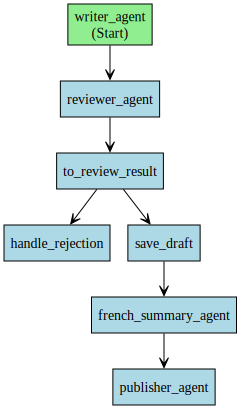

Reviewer raw response: {
  "review_result": "Yes",
  "reason": "The draft contains more than 200 words and covers all three requested aspects: the tech startup scene, enterprise adoption of AI tools, and government digital transformation initiatives in Casablanca.",
  "draft_content": "# The Rise of AI in Casablanca: Transforming Business and Society\n\nArtificial intelligence is experiencing rapid growth in Casablanca, Morocco’s bustling economic hub. As the city positions itself as a tech leader in North Africa, businesses and institutions are increasingly integrating AI solutions to stay competitive and foster innovation. The digital transformation underway is not only impacting private enterprises but also reshaping public services and government strategies.\n\nCasablanca’s tech startup scene has flourished in recent years, driven by young entrepreneurs and investors eager to capitalize on AI’s vast potential. Incubators and innovation hubs, such as Technopark and LaFactory, are nu

In [11]:
async with (
    AzureCliCredential() as credential,
    AzureAIAgentsProvider(credential=credential) as provider,
):
    writer_agent_obj = None
    reviewer_agent_obj = None
    french_agent_obj = None
    publisher_agent_obj = None
    try:
        client = AzureAIAgentClient(credential=credential)
        code_interpreter_tool = client.get_code_interpreter_tool()

        writer_agent_obj = await provider.create_agent(
            name="writer-agent",
            instructions=WriterInstructions,
            model=os.environ["AZURE_AI_MODEL_DEPLOYMENT_NAME"],
        )
        writer_agent = AgentExecutor(writer_agent_obj, id="writer_agent")

        reviewer_agent_obj = await provider.create_agent(
            name="reviewer-agent",
            instructions=ReviewerInstructions,
            model=os.environ["AZURE_AI_MODEL_DEPLOYMENT_NAME"],
        )
        reviewer_agent = AgentExecutor(reviewer_agent_obj, id="reviewer_agent")

        # OPTIONAL: French Summary agent
        french_agent_obj = await provider.create_agent(
            name="french-summary-agent",
            instructions=FrenchSummaryInstructions,
            model=os.environ["AZURE_AI_MODEL_DEPLOYMENT_NAME"],
        )
        french_summary_agent = AgentExecutor(french_agent_obj, id="french_summary_agent")

        publisher_agent_obj = await provider.create_agent(
            name="publisher-agent",
            instructions=PublisherInstructions,
            model=os.environ["AZURE_AI_MODEL_DEPLOYMENT_NAME"],
            tools=[code_interpreter_tool],
        )
        publisher_agent = AgentExecutor(publisher_agent_obj, id="publisher_agent")

        # SOLUTION — Task 5: Build the workflow
        # Core workflow (without optional agent):
        # workflow = (
        #     WorkflowBuilder(start_executor=writer_agent)
        #         .add_edge(writer_agent, reviewer_agent)
        #         .add_edge(reviewer_agent, to_review_result)
        #         .add_multi_selection_edge_group(
        #             to_review_result,
        #             [handle_rejection, save_draft],
        #             selection_func=select_targets,
        #         )
        #         .add_edge(save_draft, publisher_agent)
        #         .build()
        # )

        # OPTIONAL — with French Summary agent inserted before publisher:
        workflow = (
            WorkflowBuilder(start_executor=writer_agent)
                .add_edge(writer_agent, reviewer_agent)
                .add_edge(reviewer_agent, to_review_result)
                .add_multi_selection_edge_group(
                    to_review_result,
                    [handle_rejection, save_draft],
                    selection_func=select_targets,
                )
                .add_edge(save_draft, french_summary_agent)
                .add_edge(french_summary_agent, publisher_agent)
                .build()
        )

        # Visualise
        print("Workflow visualization:")
        viz = WorkflowViz(workflow)
        print(viz.to_mermaid())
        svg_file = viz.export(format="svg")
        if svg_file and os.path.exists(svg_file):
            try:
                display(SVG(filename=svg_file))
            except Exception:
                pass

        task = (
            "Write a blog article for the Casablanca Tech Blog based on the "
            "following topic. Once written, the reviewer will check it. If approved, "
            "the publisher will save it as a Markdown file.\n\n" + ARTICLE_TOPIC
        )

        events = await workflow.run(task)

        outputs = events.get_outputs()
        outputs = cast(list[AgentResponse], outputs)
        for output in outputs:
            print(f"{output.messages[0].author_name}: {output.text}\n")

        print("Final state:", events.get_final_state())

    finally:
        for agent_obj in [writer_agent_obj, reviewer_agent_obj, french_agent_obj, publisher_agent_obj]:
            if agent_obj is not None:
                try:
                    await provider._agents_client.delete_agent(agent_obj.id)
                except Exception:
                    pass
        print("done")